In [1]:
pip install numpy pandas matplotlib jupyter

   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.2 MB ? eta -:--:--
   -------------- ------------------------- 0.8/2.2 MB 2.3 MB/s eta 0:00:01
   ------------------ --------------------- 1.0/2.2 MB 2.5 MB/s eta 0:00:01
   ---------------------------- ----------- 1.6/2.2 MB 2.0 MB/s eta 0:00:01
   -------------------------------- ------- 1.8/2.2 MB 1.8 MB/s eta 0:00:01
   ------------------------------------- -- 2.1/2.2 MB 1.7 MB/s eta 0:00:01
   ---------------------------------------- 2.2/2.2 MB 1.7 MB/s  0:00:01
   ---------------------------------------- 0.0/17.2 MB ? eta -:--:--
    --------------------------------------- 0.3/17.2 MB ? eta -:--:--
   - -------------------------------------- 0.5/17.2 MB 1.7 MB/s eta 0:00:11
   - -------------------------------------- 0.5/17.2 MB 1.7 MB/s eta 0:00:11
   - -------------------------------------- 0.8/17.2 MB 939.1 kB/s eta 0:00:18
   - -------------------------------


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import numpy
import pandas
import matplotlib

print("OK")

OK


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(7)

days = np.arange(1, 31)

weekend = np.isin(days % 7, [6, 0])

temperature = np.round(
    np.random.uniform(-3, 3, size=30),
    1
)

sales_variation = np.random.normal(0, 4, size=30)

sales = (
    33
    + sales_variation
    + weekend * 33 * 0.20
).round().astype(int)

sales = np.maximum(sales, 1)

drinks = pd.DataFrame({
    "день": days,
    "вихідний": weekend,
    "температура": temperature,
    "продажі": sales
})

drinks

,день,вихідний,температура,продажі
0,1,False,-2.5,33
1,2,False,1.7,27
2,3,False,-0.4,31
3,4,False,1.3,24
4,5,False,2.9,37
5,6,True,0.2,38
6,7,True,0.0,37
7,8,False,-2.6,37
8,9,False,-1.4,26
9,10,False,-0.0,35


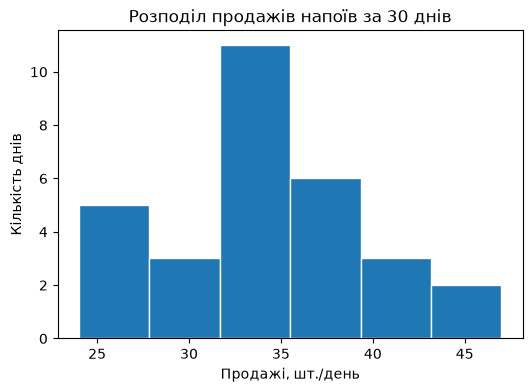

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.hist(drinks["продажі"], bins=6, edgecolor="white")

ax.set_xlabel("Продажі, шт./день")
ax.set_ylabel("Кількість днів")
ax.set_title("Розподіл продажів напоїв за 30 днів")

plt.show()

### Порівняння гістограм

Для набору з 30 значень варіант із `bins=6` дає більш змістовну картину розподілу продажів. Він показує загальну структуру даних без надмірного поділу на маленькі інтервали. При `bins=10` гістограма стає детальнішою, але через невелику кількість спостережень деякі інтервали містять мало значень, тому розподіл може виглядати менш наочно.

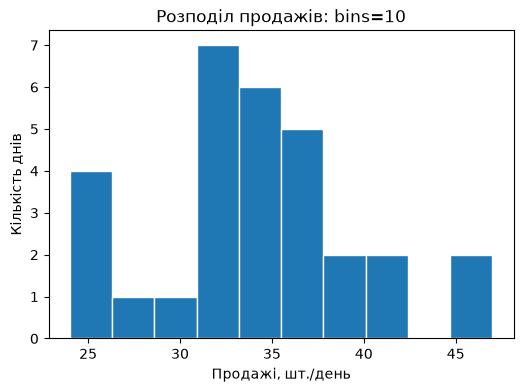

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.hist(drinks["продажі"], bins=10, edgecolor="white")

ax.set_xlabel("Продажі, шт./день")
ax.set_ylabel("Кількість днів")
ax.set_title("Розподіл продажів: bins=10")

plt.show()

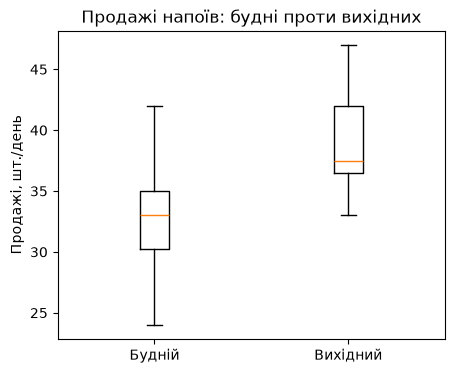

In [8]:
fig, ax = plt.subplots(figsize=(5, 4))

groups = [
    drinks.loc[~drinks["вихідний"], "продажі"],
    drinks.loc[drinks["вихідний"], "продажі"]
]

ax.boxplot(
    groups,
    tick_labels=["Будній", "Вихідний"]
)

ax.set_ylabel("Продажі, шт./день")
ax.set_title("Продажі напоїв: будні проти вихідних")

plt.show()

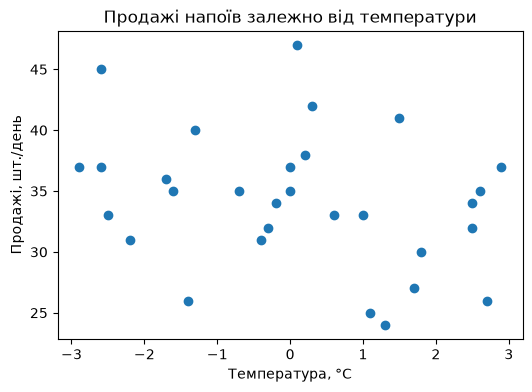

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.scatter(
    drinks["температура"],
    drinks["продажі"]
)

ax.set_xlabel("Температура, °C")
ax.set_ylabel("Продажі, шт./день")
ax.set_title("Продажі напоїв залежно від температури")

plt.show()

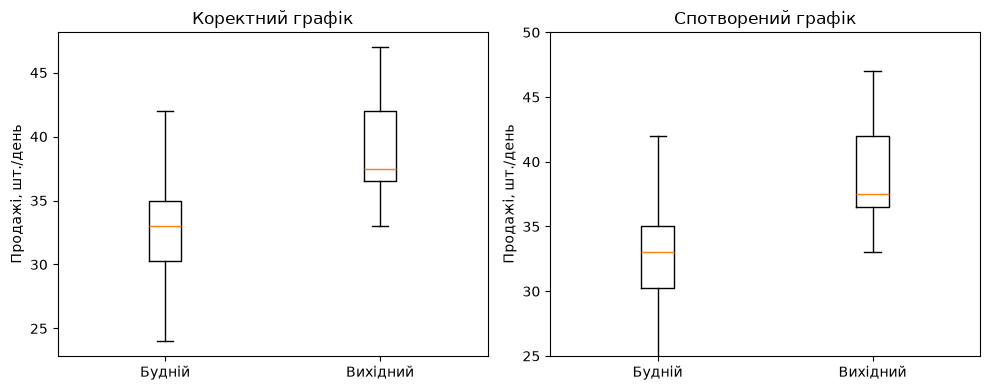

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

groups = [
    drinks.loc[~drinks["вихідний"], "продажі"],
    drinks.loc[drinks["вихідний"], "продажі"]
]

# Правильний графік
axes[0].boxplot(
    groups,
    tick_labels=["Будній", "Вихідний"]
)

axes[0].set_ylabel("Продажі, шт./день")
axes[0].set_title("Коректний графік")

# Спотворений графік
axes[1].boxplot(
    groups,
    tick_labels=["Будній", "Вихідний"]
)

axes[1].set_ylabel("Продажі, шт./день")
axes[1].set_title("Спотворений графік")

# Штучно обрізаємо вісь Y
axes[1].set_ylim(25, 50)

plt.tight_layout()
plt.show()

### Аналіз спотворення

У спотвореній версії було застосовано обрізання діапазону осі Y. 
Саме значення продажів не змінювалися, але через обмеження осі Y 
різниця між буднями та вихідними візуально здається більшою. 
Таким способом графік перебільшує реальну різницю між двома групами. 
Це є прикладом спотворення візуалізації даних.

# Контрольні питання

## 1. Чому обрізана вісь Y перебільшує різницю між категоріями?

Обрізана вісь Y змінює масштаб сприйняття графіка. Якщо вісь починається не з нуля, невелика абсолютна різниця між значеннями займає значну частину висоти графіка. Через це візуальна різниця здається більшою, хоча підписані числові значення залишаються правильними.

## 2. Коли лінійний графік буде методологічною помилкою для категоріальних даних?

Лінійний графік може бути методологічною помилкою, наприклад, при порівнянні продажів різних типів напоїв: чай, кава, сік і вода. Категорії не мають природного числового порядку та відстані між ними. Якщо з'єднати їх лінією, виникає помилкове враження безперервної зміни між категоріями. Для таких даних краще використовувати стовпчикову діаграму. Це пов'язано з номінальною шкалою вимірювання.

## 3. Чому підписи осей, одиниці вимірювання і заголовок є частиною твердження графіка?

Підписи осей, одиниці вимірювання та заголовок пояснюють, що саме показано на графіку, у яких одиницях вимірюються значення та який зв'язок або розподіл потрібно інтерпретувати. Без цих елементів читач може неправильно зрозуміти графік.

## 4. Що таке chartjunk і чому він шкодить сприйняттю графіка?

Chartjunk — це зайві графічні елементи, які не допомагають зрозуміти дані. Прикладом є 3D-ефект на звичайній стовпчиковій діаграмі, зайві декоративні елементи або непотрібні кольори. Вони можуть ускладнювати порівняння значень і відволікати увагу від даних. Тому графік повинен бути простим і містити лише ті елементи, які допомагають правильно інтерпретувати інформацію.